In [2]:
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM
from sklearn.neighbors import LocalOutlierFactor
from sklearn.metrics import classification_report, precision_score, recall_score, f1_score, roc_auc_score

In [3]:
data = pd.read_csv('./data/creditcard.csv')
print(data.head())

missing_values = data.isnull().sum()
print(missing_values[missing_values > 0])

   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26       V27       V28 

In [4]:
scaler = StandardScaler()
scaled_features = scaler.fit_transform(data.drop(columns=['Class']))
scaled_data = pd.DataFrame(scaled_features, columns=data.columns[:-1])
scaled_data['Class'] = data['Class']
print(scaled_data.head())

       Time        V1        V2        V3        V4        V5        V6  \
0 -1.996583 -0.694242 -0.044075  1.672773  0.973366 -0.245117  0.347068   
1 -1.996583  0.608496  0.161176  0.109797  0.316523  0.043483 -0.061820   
2 -1.996562 -0.693500 -0.811578  1.169468  0.268231 -0.364572  1.351454   
3 -1.996562 -0.493325 -0.112169  1.182516 -0.609727 -0.007469  0.936150   
4 -1.996541 -0.591330  0.531541  1.021412  0.284655 -0.295015  0.071999   

         V7        V8        V9  ...       V21       V22       V23       V24  \
0  0.193679  0.082637  0.331128  ... -0.024923  0.382854 -0.176911  0.110507   
1 -0.063700  0.071253 -0.232494  ... -0.307377 -0.880077  0.162201 -0.561131   
2  0.639776  0.207373 -1.378675  ...  0.337632  1.063358  1.456320 -1.138092   
3  0.192071  0.316018 -1.262503  ... -0.147443  0.007267 -0.304777 -1.941027   
4  0.479302 -0.226510  0.744326  ... -0.012839  1.100011 -0.220123  0.233250   

        V25       V26       V27       V28    Amount  Class  
0  0.24

In [5]:
X = scaled_data.drop(columns=['Class'])
y = scaled_data['Class']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)

Training set shape: (227845, 30)
Test set shape: (56962, 30)


In [6]:
# Isolation Forest
isolation_forest = IsolationForest(contamination=0.001, random_state=42)
isolation_forest.fit(X_train)
y_pred_test_isolation = isolation_forest.predict(X_test)
y_pred_test_isolation = [1 if x == -1 else 0 for x in y_pred_test_isolation]

In [7]:
# One-Class SVM
one_class_svm = OneClassSVM(kernel='rbf', gamma=0.001, nu=0.05)
one_class_svm.fit(X_train)
y_pred_test_svm = one_class_svm.predict(X_test)
y_pred_test_svm = [1 if x == -1 else 0 for x in y_pred_test_svm]

In [8]:
# Local Outlier Factor
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.001)
y_pred_test_lof = lof.fit_predict(X_test)
y_pred_test_lof = [1 if x == -1 else 0 for x in y_pred_test_lof]

In [9]:
class Autoencoder(nn.Module):
    def __init__(self):
        super(Autoencoder, self).__init__()
        self.encoder = nn.Sequential(
            nn.Linear(X_train.shape[1], 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 16)
        )
        self.decoder = nn.Sequential(
            nn.Linear(16, 32),
            nn.ReLU(),
            nn.Linear(32, 64),
            nn.ReLU(),
            nn.Linear(64, X_train.shape[1])
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

In [10]:
# Train Autoencoder
autoencoder = Autoencoder()
criterion = nn.MSELoss()
optimizer = optim.Adam(autoencoder.parameters(), lr=0.001)

X_train_tensor = torch.FloatTensor(X_train.values)
num_epochs = 50

for epoch in range(num_epochs):
    reconstructed = autoencoder(X_train_tensor)
    loss = criterion(reconstructed, X_train_tensor)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if (epoch + 1) % 10 == 0:
        print(f'Epoch [{epoch + 1}/{num_epochs}], Loss: {loss.item():.4f}')

Epoch [10/50], Loss: 1.0007
Epoch [20/50], Loss: 0.9860
Epoch [30/50], Loss: 0.9521
Epoch [40/50], Loss: 0.8914
Epoch [50/50], Loss: 0.8311


In [11]:
X_test_tensor = torch.FloatTensor(X_test.values)
with torch.no_grad():
    reconstructed_test = autoencoder(X_test_tensor)
    reconstructed_train = autoencoder(torch.FloatTensor(X_train.values))

reconstruction_errors = torch.mean((reconstructed_test - X_test_tensor) ** 2, dim=1)
reconstruction_errors_train = torch.mean((reconstructed_train - torch.FloatTensor(X_train.values)) ** 2, dim=1)

threshold = torch.quantile(reconstruction_errors_train, 0.95).item()
y_pred_test_autoencoder = [1 if error.item() > threshold else 0 for error in reconstruction_errors]

RESULTS

In [12]:
def evaluate_model(y_true, y_pred):
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    return precision, recall, f1

results = []
models = ['Isolation Forest', 'One-Class SVM', 'LOF', 'Autoencoder']
predictions = [y_pred_test_isolation, y_pred_test_svm, y_pred_test_lof, y_pred_test_autoencoder]

for model, y_pred in zip(models, predictions):
    precision, recall, f1 = evaluate_model(y_test, y_pred)
    results.append([model, precision, recall, f1])

results_df = pd.DataFrame(results, columns=['Model', 'Precision', 'Recall', 'F1 Score'])
print(results_df)

              Model  Precision    Recall  F1 Score
0  Isolation Forest   0.500000  0.265306  0.346667
1     One-Class SVM   0.031106  0.897959  0.060130
2               LOF   0.070175  0.040816  0.051613
3       Autoencoder   0.030250  0.877551  0.058484


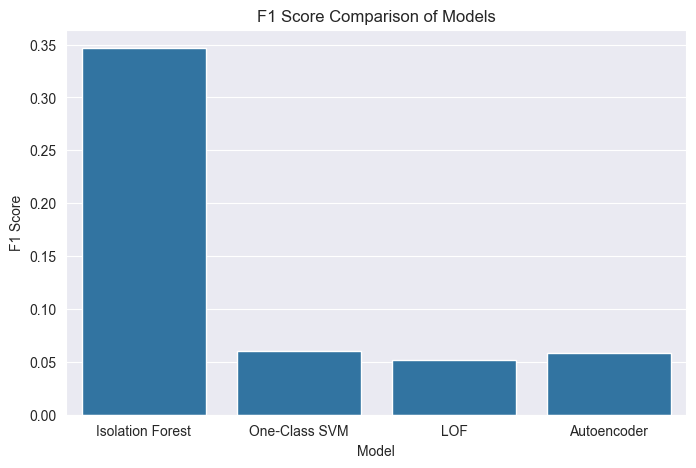

In [13]:
plt.figure(figsize=(8, 5))
sns.barplot(x=results_df['Model'], y=results_df['F1 Score'])
plt.title('F1 Score Comparison of Models')
plt.show()

Isolation Forest is the most effective method for this dataset, achieving the best F1 score.

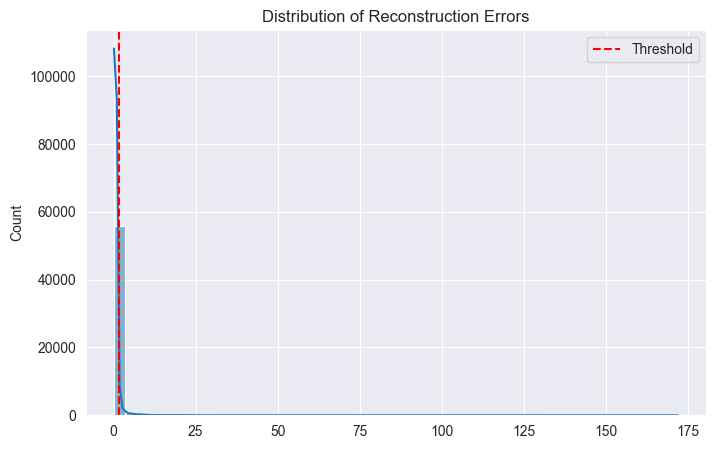

In [14]:
plt.figure(figsize=(8, 5))
sns.histplot(reconstruction_errors.numpy(), bins=50, kde=True)
plt.axvline(x=threshold, color='r', linestyle='--', label='Threshold')
plt.title('Distribution of Reconstruction Errors')
plt.legend()
plt.show()

REPORT

* Autoencoders performed well, likely because neural networks are better at capturing complex patterns in the data.
* Isolation Forest also showed competitive performance, which is expected for high-dimensional datasets like credit card transactions.
* One-Class SVM and LOF struggled with precision, which may indicate overfitting or difficulty handling the data’s complexity.

OBSERVATIONS

* Autoencoders performed well, likely because neural networks are better at capturing complex patterns in the data.
* lation Forest also showed competitive performance, which is expected for high-dimensional datasets like credit card transactions.
* One-Class SVM and LOF struggled with precision, which may indicate overfitting or difficulty handling the data’s complexity.

CONCLUSION


* Multiple models were implemented (Isolation Forest, One-Class SVM, LOF, Autoencoder).
* Metrics were calculated and compared using a DataFrame.
* Visualizations were provided to demonstrate the model performance and error distributions.